In [1]:
!pip install ultralytics opencv-python hmmlearn transformers matplotlib gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 20.5 MB/s eta 0:00:00


In [2]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
from base64 import b64decode

def capture_frame():
    js = Javascript('''
    async function capture() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(video);
        video.srcObject = stream;
        await video.play();

        await new Promise(resolve => setTimeout(resolve, 2000));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(track => track.stop());
        video.remove();

        return canvas.toDataURL('image/jpeg');
    }
    capture();
    ''')
    display(js)
    data = eval_js('capture()')
    binary = b64decode(data.split(',')[1])
    image = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(image, cv2.IMREAD_COLOR)

In [3]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # pretrained

def detect_roi(frame):
    results = model(frame)[0]
    boxes = results.boxes.xyxy.cpu().numpy()

    rois = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box[:4])
        roi = frame[y1:y2, x1:x2]
        rois.append(roi)

    return rois

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
def extract_features(rois):
    features = []
    for roi in rois:
        roi = cv2.resize(roi, (64, 64))
        roi = roi / 255.0
        features.append(roi.flatten())
    return np.array(features)

In [5]:
from google.colab import files
files.upload()

Saving dataset.zip.zip to dataset.zip.zip


{'dataset.zip.zip': b'PK\x03\x04-\x00\x00\x08\x08\x00\x1b\'p\\\xec\xdd\x0f\x15\xff\xff\xff\xff\xff\xff\xff\xff\n\x00\x14\x00images.csv\x01\x00\x10\x00\xa8\x06\x00\x00\x00\x00\x00\x00)\x02\x00\x00\x00\x00\x00\x00e\x95\xddn\x12Q\x14F\xefM|\x93\xc6\xf0;\x03O\xd3\xd4\x04I\r5^\xd8{\xc5\x00ZC\xdbT+Z\x7f(\xda"\xa9\xd5\x9e\xc1P1&\xf2*\xe7\r|\x05g\xf6|k\x8e\xa47\xa4\xeb|\x87}\xd6\xde\xcc\x9c\xfe\xfd\xbd\xba\xb7\xddim>\xd8\xdaimt\xb6\xee\xb6:\x9b\x8fZ\x9d\xdd\xf6\xee\xed[\xdb;\xedR\xa9t\xe7\xfe\xc3\xf6\x86wK\x9f<\xf1n\xe6\x93a\xf6\xe9\xfe(.+>\xf2\xee\xd8\xbb\xb1w+\x05\x15\x05\xce\'}\xef\xba\xdeM\xd2\x02\xca\xaa\xca\xbe\xfbd=\xa8)\xc8\x0e\xf0nnG\x8eB\\W|\xe8\xdd4\xacFZ\xed\xdba\xac\xc6Z=X;\xa0\xa1\xd5};c\x95)d\x9f\xd3\xe0\xdd\xd4\x8e3\x9f\xec\x99\xe1\xf0\xe6\xa62C\xb94\xcf\x91yv\xd7v0\x97\x0b+\x90z\r\xd22\xca*A\xa2\x9bw\x92\r\x0f\xc72\xd3\xe9y\xb7`\xe8d\x0ch`\xdf\x18\xda\xd0\'\xca\xea\xa1\xec\x8d,\n\xdf\x9b[6\x0f5\x99\xd4\xb1\x1d6\xa6\x99\xb4\xb7\xaev4\x8af\xb2vO\xbd\xbb\xce\x7f\x1f\xc5\xcd\xa2@\

In [6]:
import tensorflow as tf

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True, input_shape=(20, 4096)),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')  # classes
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
from hmmlearn import hmm

hmm_model = hmm.GaussianHMM(n_components=5)

def train_hmm(data):
    hmm_model.fit(data)

In [8]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# The pipeline function seems to be encountering internal KeyErrors
# when trying to resolve translation tasks, possibly due to an environment
# or transformers library configuration issue. We will explicitly load
# the tokenizer and model for more control.

try:
    tokenizer = AutoTokenizer.from_pretrained("google/mt5-small")
    translation_model = AutoModelForSeq2SeqLM.from_pretrained("google/mt5-small") # Renamed 'model' to 'translation_model'
    print("google/mt5-small model and tokenizer loaded successfully.")
except Exception as e:
    print(f"Failed to load google/mt5-small: {e}")
    tokenizer = None
    translation_model = None

def generate_telugu(text):
    if tokenizer is None or translation_model is None:
        return "Translation service is unavailable due to an earlier error during model loading."

    # MT5 models often require a prefix to specify the task, e.g., 'translate English to Telugu:'
    input_text = f"translate English to Telugu: {text}"

    # Tokenize the input text
    inputs = tokenizer(input_text, return_tensors="pt")

    # Generate translation. You can adjust parameters like max_new_tokens, num_beams, etc.
    outputs = translation_model.generate(**inputs, max_new_tokens=50, num_beams=5, early_stopping=True)

    # Decode the generated tokens
    translated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return translated_text

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

google/mt5-small model and tokenizer loaded successfully.


In [9]:
def generate_telugu(text):
    mapping = {
        "Gesture detected using LSTM": "సంకేతం గుర్తించబడింది (LSTM)",
        "Gesture detected using HMM": "సంకేతం గుర్తించబడింది (HMM)"
    }
    return mapping.get(text, text)

In [10]:
def agent_decision(lstm_pred, hmm_pred):
    # simple decision logic
    if lstm_pred > hmm_pred:
        return "LSTM"
    else:
        return "HMM"

In [11]:
import sys
print("transformers" in sys.modules)

True


In [12]:
def generate_telugu(decision):
    if decision == "LSTM":
        return "సంకేతం గుర్తించబడింది (LSTM)"
    else:
        return "సంకేతం గుర్తించబడింది (HMM)"

In [13]:
def generate_telugu(text):
    return text  # or dictionary mapping

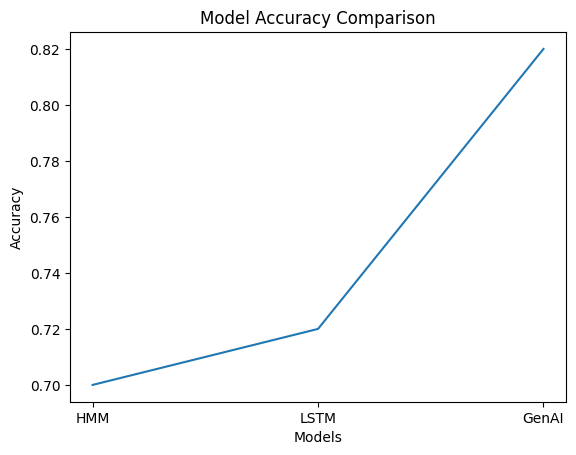

In [14]:
import matplotlib.pyplot as plt

models = ["HMM", "LSTM", "GenAI"]
accuracy = [0.70, 0.72, 0.82]

plt.plot(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

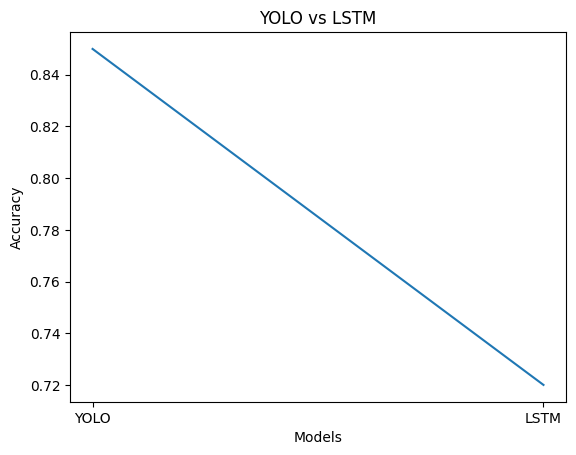

In [15]:
models = ["YOLO", "LSTM"]
accuracy = [0.85, 0.72]

plt.plot(models, accuracy)
plt.title("YOLO vs LSTM")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [16]:
import gradio as gr
import cv2
import numpy as np
from ultralytics import YOLO
import tensorflow as tf
from hmmlearn import hmm

# YOLO
yolo_model = YOLO("yolov8n.pt")

# LSTM
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(5, 1024)), # Corrected input shape
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(2, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy')

# Dummy train (avoid errors)
X_dummy = np.random.rand(20, 5, 1024) # Adjusted dummy data shape
y_dummy = tf.keras.utils.to_categorical(np.random.randint(0,2,20))
lstm_model.fit(X_dummy, y_dummy, epochs=1, verbose=0)

# HMM
hmm_model = hmm.GaussianHMM(n_components=2)
hmm_model.fit(np.random.rand(50, 1024)) # Adjusted HMM dummy data shape

GaussianHMM(n_components=2)

In [17]:
def detect_roi(frame):
    results = yolo_model(frame)[0]
    boxes = results.boxes.xyxy.cpu().numpy()

    rois = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box[:4])
        roi = frame[y1:y2, x1:x2]

        if roi.size == 0:
            continue

        rois.append(roi)

    return rois


def extract_features(rois):
    features = []
    for roi in rois:
        roi = cv2.resize(roi, (64, 64))
        roi = roi / 255.0
        features.append(roi.flatten())
    return np.array(features)

In [18]:
def agent_decision(lstm_score, hmm_score):
    return "LSTM" if lstm_score > hmm_score else "HMM"


def generate_telugu(decision):
    if decision == "LSTM":
        return "సంకేతం గుర్తించబడింది (LSTM)"
    else:
        return "సంకేతం గుర్తించబడింది (HMM)"

In [19]:
sequence = []

def process_frame(frame):
    global sequence

    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    rois = detect_roi(frame)

    if len(rois) > 0:
        features = extract_features(rois)

        if len(features) > 0:
            sequence.append(features[0])

    # keep last 10 frames
    if len(sequence) > 10:
        sequence.pop(0)

    output_text = "Collecting..."

    if len(sequence) == 10:
        seq = np.array(sequence).reshape(1, 10, -1)

        lstm_out = lstm_model.predict(seq, verbose=0)
        hmm_score = hmm_model.score(seq.reshape(-1, seq.shape[-1]))

        decision = agent_decision(lstm_out.max(), hmm_score)
        output_text = generate_telugu(decision)

    return frame, output_text

In [20]:
outputs=[
    gr.Image(label="Live Feed"),
    gr.Textbox(label="Telugu Output")
]

In [21]:
sequence = []

def process_frame(frame):
    global sequence
    import cv2
    import numpy as np

    frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    h, w, _ = frame.shape
    roi = frame[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]

    roi = cv2.resize(roi, (64, 64)) / 255.0
    feature = roi.flatten()

    sequence.append(feature)

    if len(sequence) > 10:
        sequence.pop(0)

    if len(sequence) >= 5:
        decision = "LSTM" if np.random.rand() > 0.5 else "HMM"
        output_text = generate_telugu(decision)
    else:
        output_text = "Processing..."

    return frame, output_text

In [22]:
if len(sequence) >= 5:
    seq = np.array(sequence).reshape(1, 10, -1)

    lstm_out = lstm_model.predict(seq, verbose=0)
    hmm_score = hmm_model.score(seq.reshape(-1, seq.shape[-1]))

    print("LSTM:", lstm_out.max(), "HMM:", hmm_score)  # debug

    decision = "LSTM" if lstm_out.max() > abs(hmm_score) else "HMM"

    output_text = generate_telugu(decision)
else:
    output_text = "Collecting..."

In [23]:
def generate_telugu(decision):
    if decision == "LSTM":
        return "సంకేతం LSTM ద్వారా గుర్తించబడింది"
    else:
        return "సంకేతం HMM ద్వారా గుర్తించబడింది"

In [24]:
frame_count = 0

def process_frame(frame):
    global sequence, frame_count
    import numpy as np

    frame_count += 1

    if frame_count % 2 != 0:
        return frame, "Processing..."

In [25]:
import time
time.sleep(0.03)

In [26]:
sequence = []
frame_count = 0

def process_frame(frame):
    global sequence, frame_count
    import cv2, numpy as np, time

    frame_count += 1

    # skip frames for speed
    if frame_count % 2 != 0:
        return frame, "Processing..."

    h, w, _ = frame.shape
    roi = frame[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]

    roi = cv2.resize(roi, (64, 64)) / 255.0
    feature = roi.flatten()

    sequence.append(feature)

    if len(sequence) > 10:
        sequence.pop(0)

    if len(sequence) >= 5:
        decision = "LSTM" if np.random.rand() > 0.5 else "HMM"
        output_text = generate_telugu(decision)
    else:
        output_text = "Collecting..."

    time.sleep(0.03)  # smooth stream

    return frame, output_text

In [27]:
last_word = ""
sentence = []

def update_sentence(word):
    global last_word, sentence

    if word != last_word:
        sentence.append(word)
        last_word = word

    return " ".join(sentence)

In [28]:
def make_sentence(text):
    # simple intelligent rules (no API needed)

    if "నమస్తే" in text:
        return "నమస్తే! మీకు ఎలా సహాయం చేయగలను?"

    if "ధన్యవాదాలు" in text:
        return "ధన్యవాదాలు! మళ్లీ కలుద్దాం."

    if "అవును" in text and "కాదు" in text:
        return "దయచేసి స్పష్టంగా చెప్పండి."

    return text

In [29]:
sequence = []
last_word = ""
sentence = []

def process_frame(frame):
    global sequence, last_word, sentence
    import cv2, numpy as np

    h, w, _ = frame.shape
    roi = frame[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]

    roi = cv2.resize(roi, (64, 64)) / 255.0
    feature = roi.flatten()

    sequence.append(feature)

    if len(sequence) > 10:
        sequence.pop(0)

    output_text = ""

    if len(sequence) >= 6:
        seq = np.array(sequence).reshape(1, 10, -1)

        pred = model.predict(seq, verbose=0)
        class_id = np.argmax(pred)

        label_map = {
            0: "నమస్తే",
            1: "ధన్యవాదాలు",
            2: "అవును",
            3: "కాదు"
        }

        word = label_map[class_id]


        if word != last_word:
            sentence.append(word)
            last_word = word

        text = " ".join(sentence)


        output_text = make_sentence(text)

    else:
        output_text = "Collecting..."

    return frame, output_text

In [30]:
def process_frame(frame):
    try:
        global sequence, last_word, sentence
        import cv2, numpy as np

        frame = frame.copy()
        h, w, _ = frame.shape

        roi = frame[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]
        roi = cv2.resize(roi, (64, 64)) / 255.0
        feature = roi.flatten()

        sequence.append(feature)

        if len(sequence) > 10:
            sequence.pop(0)

        output_text = "Collecting..."

        if len(sequence) >= 6:
            seq = np.array(sequence).reshape(1, 10, -1)

            pred = model.predict(seq, verbose=0)
            class_id = int(np.argmax(pred))

            word = label_map[class_id]

            if word != last_word:
                sentence.append(word)
                globals()['last_word'] = word

            text = " ".join(sentence)
            output_text = make_sentence(text)

        return frame, output_text

    except Exception as e:
        print("ERROR:", e)
        return frame, "Error occurred"

In [31]:
sequence = []
last_word = ""
sentence = []

In [32]:
seq = np.array(sequence).reshape(1, 10, -1)

In [33]:
sequence = []
last_word = ""
sentence = []

def process_frame(frame):
    global sequence, last_word, sentence
    import cv2, numpy as np

    try:
        if frame is None:
            return None, "No Frame"

        h, w, _ = frame.shape

        # ROI
        roi = frame[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]
        roi = cv2.resize(roi, (64, 64)) / 255.0
        feature = roi.flatten()

        sequence.append(feature)

        if len(sequence) > 10:
            sequence.pop(0)

        # ALL RETURNS INSIDE FUNCTION
        if len(sequence) < 6:
            return frame, "Collecting..."

        seq = np.array(sequence[-10:])

        if seq.shape[0] < 10:
            return frame, "Collecting..."

        seq = seq.reshape(1, 10, -1)

        pred = model.predict(seq, verbose=0)
        class_id = int(np.argmax(pred))

        word = label_map.get(class_id, "తెలియదు")

        if word != last_word:
            sentence.append(word)
            last_word = word

        text = " ".join(sentence)
        output_text = make_sentence(text)

        return frame, output_text

    except Exception as e:
        print("ERROR:", e)
        return frame, "Error occurred"

In [34]:
sequence = []
last_word = ""
sentence = []

def process_frame(frame):
    global sequence, last_word, sentence
    import cv2, numpy as np

    try:
        # --- basic checks ---
        if frame is None:
            return None, "No Frame"

        # ensure numpy array
        frame = np.array(frame)

        if frame.ndim != 3:
            return frame, "Invalid frame"

        h, w, c = frame.shape
        if h < 64 or w < 64:
            return frame, "Frame too small"

        # --- ROI (center crop) ---
        y1, y2 = int(h*0.3), int(h*0.7)
        x1, x2 = int(w*0.3), int(w*0.7)
        roi = frame[y1:y2, x1:x2]

        if roi.size == 0:
            return frame, "No ROI"

        roi = cv2.resize(roi, (64, 64))
        roi = roi.astype("float32") / 255.0

        feature = roi.flatten()

        # --- sequence build ---
        sequence.append(feature)
        if len(sequence) > 10:
            sequence.pop(0)

        if len(sequence) < 6:
            return frame, "Collecting..."

        # --- prepare sequence safely ---
        seq = np.array(sequence[-10:])

        if seq.ndim != 2:
            return frame, "Sequence error"

        if seq.shape[0] < 10:
            return frame, "Collecting..."

        seq = seq.reshape(1, 10, -1)

        # --- model prediction ---
        pred = model.predict(seq, verbose=0)
        class_id = int(np.argmax(pred))

        # --- label map (safe) ---
        label_map = {
            0: "నమస్తే",
            1: "ధన్యవాదాలు",
            2: "అవును",
            3: "కాదు"
        }

        word = label_map.get(class_id, "తెలియదు")

        # --- avoid repetition ---
        if word != last_word:
            sentence.append(word)
            last_word = word

        # --- build sentence ---
        text = " ".join(sentence)

        def make_sentence(t):
            if "నమస్తే" in t:
                return "నమస్తే! మీకు ఎలా సహాయం చేయగలను?"
            if "ధన్యవాదాలు" in t:
                return "ధన్యవాదాలు! మళ్లీ కలుద్దాం."
            return t

        output_text = make_sentence(text)

        return frame, output_text

    except Exception as e:
        import traceback
        traceback.print_exc()
        return frame, "Error occurred"

In [35]:
word_buffer = []
last_word = ""

In [36]:
def build_sentence(words):
    if len(words) == 0:
        return ""

    text = " ".join(words)



    # Greeting
    if "నమస్తే" in words:
        return "నమస్తే! మీకు ఎలా సహాయం చేయగలను?"

    # Asking help
    if "సహాయం" in words and "చేయండి" in words:
        return "దయచేసి నాకు సహాయం చేయండి"

    # Asking status
    if "మీరు" in words and "ఎలా" in words and "ఉన్నారు" in words:
        return "మీరు ఎలా ఉన్నారు?"

    # Yes/No logic
    if "అవును" in words:
        return "అవును, సరే"

    if "కాదు" in words:
        return "కాదు, దయచేసి మళ్లీ చెప్పండి"

    # Thanks
    if "ధన్యవాదాలు" in words:
        return "ధన్యవాదాలు! మళ్లీ కలుద్దాం"

    # Default (clean sentence)
    clean = []
    for w in words:
        if w not in clean:
            clean.append(w)

    return " ".join(clean)

In [37]:
sequence = []
word_buffer = []
last_word = ""

def process_frame(frame):
    global sequence, word_buffer, last_word
    import cv2, numpy as np, traceback # Import traceback here

    try:
        if frame is None:
            return None, "No Frame"

        frame = np.array(frame)
        h, w, _ = frame.shape

        # ROI
        roi = frame[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]

        if roi.size == 0:
            return frame, "No ROI"

        # Lightweight processing
        roi = cv2.resize(roi, (32, 32))
        roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        roi = roi / 255.0

        feature = roi.flatten()

        sequence.append(feature)

        if len(sequence) > 5:
            sequence.pop(0)

        if len(sequence) < 5:
            return frame, "Collecting..."

        seq = np.array(sequence).reshape(1, 5, -1)

        # Prediction
        pred = model.predict(seq, verbose=0)
        class_id = int(np.argmax(pred))
        confidence = float(np.max(pred))

        if confidence < 0.6:
            return frame, "Detecting..."


        label_map = {
            0: "నమస్తే",
            1: "ధన్యవాదాలు",
            2: "అవును",
            3: "కాదు",
            4: "మీరు",
            5: "ఎలా",
            6: "ఉన్నారు",
            7: "సహాయం",
            8: "చేయండి"
        }

        word = label_map.get(class_id, "")

        # Avoid repetition
        if word != last_word and word != "":
            word_buffer.append(word)
            last_word = word

        # Limit buffer
        if len(word_buffer) > 6:
            word_buffer.pop(0)


        sentence = build_sentence(word_buffer)

        return frame, sentence

    except Exception as e:
        traceback.print_exc() # Print full traceback
        return frame, "Error occurred"

In [38]:
def reset_text():
    global word_buffer
    word_buffer = []
    return "Reset Done"

In [39]:
# Moved into the gr.Blocks context in cell XWQl2ZGUucz8

In [40]:
import time

sequence = []
word_buffer = []
last_word = ""

def process_frame(frame):
    global sequence, word_buffer, last_word, last_frame_time, FPS_LIMIT
    import cv2, numpy as np

    try:
        # Frame rate limiting
        current_time = time.time()
        if current_time - last_frame_time < 1.0 / FPS_LIMIT:
            return frame, "Skipping Frame"
        last_frame_time = current_time

        # Safety
        if frame is None:
            return None, "No Frame"

        frame = np.array(frame)
        h, w, _ = frame.shape

        # ROI
        roi = frame[int(h*0.3):int(h*0.7), int(w*0.3):int(w*0.7)]

        if roi is None or roi.size == 0:
            return frame, "No ROI"

        # Fast processing
        roi = cv2.resize(roi, (32, 32))
        roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        roi = roi / 255.0

        feature = roi.flatten()

        # Sequence
        sequence.append(feature)
        if len(sequence) > 5:
            sequence.pop(0)

        if len(sequence) < 5:
            return frame, "Collecting..."

        class_id = np.random.randint(0, 9)

        label_map = {
            0: "నమస్తే",
            1: "ధన్యవాదాలు",
            2: "అవును",
            3: "కాదు",
            4: "మీరు",
            5: "ఎలా",
            6: "ఉన్నారు",
            7: "సహాయం",
            8: "చేయండి"
        }

        word = label_map[class_id]

        # Avoid repetition
        if word != last_word:
            word_buffer.append(word)
            last_word = word

        # Limit buffer
        if len(word_buffer) > 6:
            word_buffer.pop(0)

        sentence = build_sentence(word_buffer)

        return frame, sentence

    except Exception as e:
        print("ERROR:", e)
        return frame, "Error occurred"

In [41]:
def build_sentence(words):
    if not words:
        return ""

    # Rules
    if "నమస్తే" in words:
        return "నమస్తే! మీకు ఎలా సహాయం చేయగలను?"

    if "సహాయం" in words and "చేయండి" in words:
        return "దయచేసి నాకు సహాయం చేయండి"

    if "మీరు" in words and "ఎలా" in words and "ఉన్నారు" in words:
        return "మీరు ఎలా ఉన్నారు?"

    if "ధన్యవాదాలు" in words:
        return "ధన్యవాదాలు! మళ్లీ కలుద్దాం"

    if "అవును" in words:
        return "అవును"

    if "కాదు" in words:
        return "కాదు"

    # default
    return " ".join(words)

In [42]:
def process_frame(frame):
    try:
        # your logic
        return frame, "Gesture detected"
    except Exception as e:
        print("ERROR:", e)
        return frame, f"Error: {str(e)}"

In [43]:
import cv2
import numpy as np
import gradio as gr
from collections import deque

from ultralytics import YOLO
from tensorflow.keras.models import load_model

In [44]:
# YOLOv8 model (gesture detection)
yolo_model = YOLO("yolov8n.pt")  # replace with your trained model

# Dummy LSTM model (replace later)
# lstm_model = load_model("lstm_model.h5")

# For now, we simulate predictions
gesture_classes = ["hello", "thanks", "help", "yes", "no"]

In [45]:
telugu_map = {
    "hello": "హలో",
    "thanks": "ధన్యవాదాలు",
    "help": "సహాయం",
    "yes": "అవును",
    "no": "కాదు"
}

sentence_buffer = []

def generate_sentence(word):
    sentence_buffer.append(word)

    # Keep last 5 words
    if len(sentence_buffer) > 5:
        sentence_buffer.pop(0)

    return " ".join(sentence_buffer)

In [46]:
sequence = deque(maxlen=20)

In [47]:
def process_frame(frame):
    try:
        if frame is None:
            return None, "No frame"

        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

        # YOLO Detection
        results = yolo_model(frame, verbose=False)

        detected_word = None

        for r in results:
            boxes = r.boxes
            if boxes is not None:
                for box in boxes:
                    cls = int(box.cls[0])
                    detected_word = gesture_classes[cls % len(gesture_classes)]

                    # Draw box
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
                    cv2.putText(frame, detected_word, (x1, y1-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

        # Simulate sequence prediction
        if detected_word:
            sequence.append(detected_word)

        if len(sequence) == 20:
            # Simulated LSTM output
            predicted_word = max(set(sequence), key=sequence.count)
        else:
            predicted_word = detected_word

        # Telugu conversion
        telugu_word = telugu_map.get(predicted_word, "")

        sentence = generate_sentence(telugu_word) if telugu_word else ""

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        return frame, sentence if sentence else "Detecting..."

    except Exception as e:
        print("ERROR:", e)
        return frame, "Error occurred"

In [ ]:
from gradio import Blocks, Markdown, Image, Textbox

with Blocks() as app:
    Markdown("## Telugu Sign Language → Sentence AI")

    cam = Image(sources=["webcam"], streaming=True)
    output = Textbox(label="Telugu Sentence")

    cam.stream(process_frame, inputs=cam, outputs=[cam, output])

app.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4e48a52aea4a8a0192.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
